In [1]:
import numpy as np
from scipy import fft 
from matplotlib import pyplot as plt
 
import matplotlib.animation
from matplotlib.patches import Arc
import matplotlib.patches as patches

from IPython.core.display import HTML
HTML("""
<style>
.RenderedHTMLCommon{
    display: table-cell;
    text-align: center;
    vertical-align: middle;
}
.jp-RenderedImage{
    display: table-cell;
    text-align: center;
    vertical-align: middle;
}
.jp-RenderedSVG{
    display: table-cell;
    text-align: center;
    vertical-align: middle;
}
</style>
""")

# The Frequency Domain

Time-frequency-transforms, like the Fourier transform, aim at calculating a frequency-domain equivalent of a time series.
The frequency-domain representation - referred to as the spectrum - gives insight into the composition of time series and hence of musical signals. 




-----
# The  Fourier Transform

The Fourier transform is an integral transform that takes a real-valued time domain signal (that is the typical DSP application - it works for complex input signals too) and converts it into a complex-valued signal in the frequency domain:

$${  F(\omega) = \frac{1}{2 \pi} \int _{-\infty }^{\infty }f(t)\ e^{-i \omega t}\,dt,\quad ~  \mathrm{for~all} ~ k \in \mathbb {R}}$$


The inverse Fourier transform, on the other hand, turns a complex valued frequency domain signal into a time domain signal:

$${ f(t) =\int _{-\infty }^{\infty } F(\omega)\ e^{i \omega t}\,d\omega,\quad ~ \mathrm{for~all} ~ x \in \mathbb {R}}$$

-----

## Fourier Transform in Words

**The Fourier transform measures the correlation of the input signal with a set of complex oscillations with different angular frequencies $\omega$.**


-----

## Sine + Cosine Representation

The above equation for th Fourier transform is called the *polar form*.
With Euler's formula, the Fourier transform can be rewritten in terms of sine and cosine, making it more graspable:

$$
\begin{eqnarray}
\mathcal F(\omega) & = & \int _{-\infty }^{\infty }f(t) (\cos(\omega t) - j \sin(\omega t)) ,dt \\
& = & \left( \int _{-\infty }^{\infty }f(t) \cos(\omega t) ,dt \right) - j \left( \int _{-\infty }^{\infty }f(t) \sin(\omega t) ,dt \right) 
\end{eqnarray}
$$

The above equation shows that the Fourier transform calculates the correlation of $f(t)$ with both a sine and a cosine at different angular frequencies. The correlation with the cosine will become the *real part* of the transformed signal, whereas the correlation with the sine will become the *imaginary part* (it is multiplied with $j$).

At this point it is crucial to note that sine and cosine are perpendicular - they have a phase shift of $90$ degrees or $\pi/2$:

$$ \cos(\varphi) = \cos(\varphi + \pi/2)$$

When observed in the complex plane, this pair of sine and cosine will rotate as follows, for a fixed $\omega$:

In [2]:
fig = plt.figure()
ax = plt.subplot(1,1,1)

N = 200

# setup

ax.set_xlabel('Real',loc='right')
ax.set_ylabel('Imag',loc='top')

ax.set_xlim([-1.1,1.1])
ax.set_ylim([-1.1,1.1])
ax.set_aspect( 1 )

ax.spines['left'].set_position('center')
ax.spines['bottom'].set_position('center')
ax.spines['right'].set_color('none')
ax.spines['top'].set_color('none')

ax.xaxis.set_ticks([-1,0,1]) 
ax.yaxis.set_ticks([-1,0,1])

real=0
imag=0

z1, = ax.plot([0,real],[0,imag], linewidth=2, color='m')
z2, = ax.plot([0,real],[0,imag], linewidth=2, color='c')

#rea, = ax.plot([0,real],[0,0],color='red', linewidth=2)
#ima, = ax.plot([0,0],[imag,0],color='green', linewidth=2)


def animate(s):

    phi1 = s/100 * np.pi;
    phi2 = phi1+(np.pi/2);
    
    real = np.cos(phi1)
    imag = np.sin(phi1)
    z1.set_data([0,real],[0,imag]);

    real = np.cos(phi2)
    imag = np.sin(phi2)
    z2.set_data([0,real],[0,imag]);


a = matplotlib.animation.FuncAnimation(fig, animate, frames=N);
plt.close()
from IPython.display import HTML
HTML(a.to_jshtml())


-----
# Intepreting the Fourier Transform

## Magnitude
 
Since the output of the Fourier transform is complex, it cannot be visualized in a 2-dimensional plot.
The complex transformed signal can be treated in the same way complex numbers are treated.
The magnitude will give information on the strength of components, ignoring their phase:


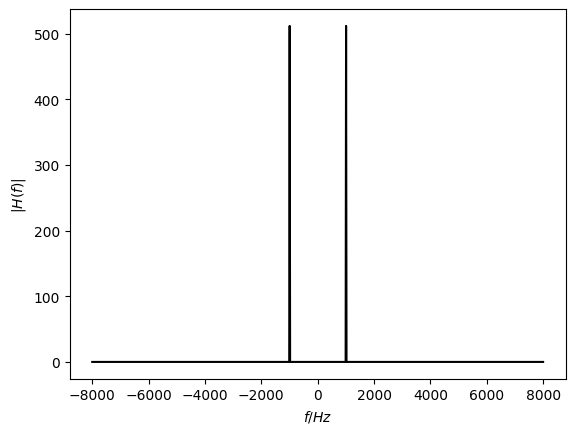

In [3]:
fs = 16000
N  = 1024
f0 = 1000
x  = np.sin(2*np.pi*(f0/fs)*(np.linspace(0,N-1,N)))
X  = abs(fft.fftshift(fft.fft(x)))
f  = np.linspace(-fs/2,fs/2,N)
k  = np.linspace(0,N-1,N)

ax = plt.subplot(1,1,1)
ax.plot(f,X,'k');
ax.set_xlabel('$f/Hz$');
ax.set_ylabel('$|H(f)|$');

-----

## Phase
 
The phase shift of $\pi/2$ between the *real part* and the *imaginary part* makes it possible to capture the phase properties of the input signal.


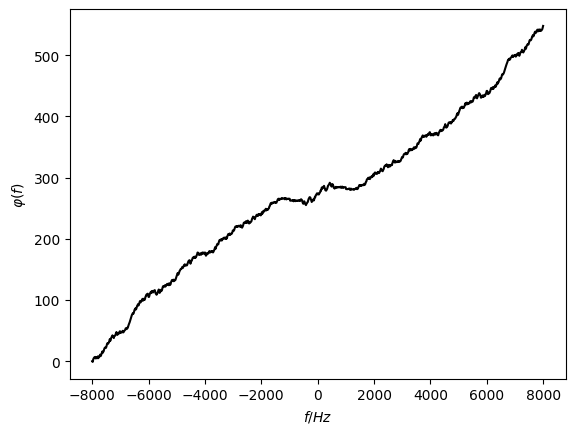

In [4]:
fs = 16000
N  = 1024
f0 = 1000
x  = np.sin(2*np.pi*(f0/fs)*(np.linspace(0,N-1,N)))
X  = np.unwrap(np.angle(fft.fftshift(fft.fft(x))))
f  = np.linspace(-fs/2,fs/2,N)
k  = np.linspace(0,N-1,N)

ax = plt.subplot(1,1,1)
ax.plot(f,X,'k');
ax.set_xlabel('$f/Hz$');
ax.set_ylabel('$\\varphi(f)$');

-----

# The Convolution Theorem

According to the convolution theorem, a convolution in the time domain is a multiplication in the frequency domain, with the inverse Fourier transform $\mathcal{F}^{-1}$: 

$$ a(t) * b(t) = \mathcal{F}^{-1} (AB)$$

And vice versa - a multiplication in the time domain equals a convolution in the frequency domain:

$$ a(t)  b(t) = \mathcal F^{-1} (A*B)$$

The convolution theorem has mutliple applications in digital signal processing.


## Symmetry and *Negative Frequencies*

For real-valued signals, the Fourier transform delivers a congruent symmetric output.
This means that only half of the transformed signal is relevant.


# Assumption of Stationarity

When applying the Fourier transform in signal processing and analysis, it has to be assumed that the input signal is stationary. That means it must not change its characeristic properties within the timeframe that is transformed.
In general, it is thus not helpful to perform such a transform on a complete piece of recorded audio (like music or speech).
A solution to this problem will be introduced with the STFT in future sections. 